In [9]:
def download_data(ticker='BTC-USD', period='5y'):
    print(f"Downloading {ticker} data...")
    data = yf.download(ticker, period=period, interval='1d')
    
    # 1. Check karein agar data khali toh nahi hai
    if data.empty:
        print("Error: No data downloaded. Check your internet or ticker symbol.")
        return None

    # 2. Handling Multi-index or Single Index (yfinance fix)
    if isinstance(data.columns, pd.MultiIndex):
        # Agar MultiIndex hai, toh level 0 se 'Close' uthayenge
        # Hum .xs use karke seedha DataFrame nikalenge
        data = data.xs('Close', axis=1, level=0)
    else:
        # Agar normal index hai, toh sirf 'Close' column rakhenge
        data = data[['Close']]
    
    # 3. Ensure karein ki ye DataFrame hi rahe (Just in case it became a Series)
    if isinstance(data, pd.Series):
        data = data.to_frame(name='Close')
    
    # 4. Clean column naming
    data.columns = ['Close']
    
    data.to_csv('data/bitcoin_raw.csv')
    return data

In [2]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("bitcoin_5y_data.csv")

print(df.head())
print(df.info())

# ==============================
# 3. Data Preprocessing
# ==============================

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df.set_index('Date', inplace=True)

# ==============================
# 4. Feature Engineering
# ==============================

# Moving Averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

# Daily Return
df['Return'] = df['Close'].pct_change()

# Volatility
df['Volatility'] = df['Return'].rolling(7).std()

df.dropna(inplace=True)

# ==============================
# 5. Feature Selection
# ==============================

features = ['Open','High','Low','Volume',
            'MA_7','MA_30','Return','Volatility']

X = df[features]
y = df['Close']

# ==============================
# 6. Scaling
# ==============================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 7. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

# ==============================
# 8. Model Training
# ==============================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 9. Prediction
# ==============================

predictions = model.predict(X_test)

# ==============================
# 10. Evaluation
# ==============================

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

# ==============================
# 11. Visualization
# ==============================

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="Actual Price")
plt.plot(y_test.index, predictions, label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction")
plt.show()

# ==============================
# 12. Future Prediction (Next Day)
# ==============================

last_data = X_scaled[-1].reshape(1,-1)
future_price = model.predict(last_data)

print("Next Day Predicted Price:", future_price[0])

        Price           Close            High             Low           Open  \
0      Ticker         BTC-USD         BTC-USD         BTC-USD        BTC-USD   
1        Date             NaN             NaN             NaN            NaN   
2  2021-05-03  57200.29296875  58973.30859375  56590.87109375  56620.2734375   
3  2021-05-04   53333.5390625   57214.1796875  53191.42578125  57214.1796875   
4  2021-05-05   57424.0078125  57911.36328125   52969.0546875  53252.1640625   

        Volume  
0      BTC-USD  
1          NaN  
2  51713139031  
3  68564706967  
4  69241316747  
<class 'pandas.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1829 non-null   str  
 1   Close   1828 non-null   str  
 2   High    1828 non-null   str  
 3   Low     1828 non-null   str  
 4   Open    1828 non-null   str  
 5   Volume  1828 non-null   str  
dtypes: str(6)
memory usage: 217.8 KB
None

KeyError: 'Date'

In [4]:
print(df.columns)

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [5]:
df = pd.read_csv(
    "bitcoin_5y_data.csv",
    index_col=0,
    parse_dates=True
)

C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_31784\1141416361.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


In [6]:
print(df.head())
print(df.index)

                     Close            High             Low           Open  \
Price                                                                       
Ticker             BTC-USD         BTC-USD         BTC-USD        BTC-USD   
Date                   NaN             NaN             NaN            NaN   
2021-05-03  57200.29296875  58973.30859375  56590.87109375  56620.2734375   
2021-05-04   53333.5390625   57214.1796875  53191.42578125  57214.1796875   
2021-05-05   57424.0078125  57911.36328125   52969.0546875  53252.1640625   

                 Volume  
Price                    
Ticker          BTC-USD  
Date                NaN  
2021-05-03  51713139031  
2021-05-04  68564706967  
2021-05-05  69241316747  
Index(['Ticker', 'Date', '2021-05-03', '2021-05-04', '2021-05-05',
       '2021-05-06', '2021-05-07', '2021-05-08', '2021-05-09', '2021-05-10',
       ...
       '2026-04-24', '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28',
       '2026-04-29', '2026-04-30', '2026-05-01

In [7]:
import pandas as pd

df = pd.read_csv(
    "bitcoin_5y_data.csv",
    index_col=0,
    parse_dates=True
)

# Clean columns
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

                     Close            High             Low           Open  \
Price                                                                       
Ticker             BTC-USD         BTC-USD         BTC-USD        BTC-USD   
Date                   NaN             NaN             NaN            NaN   
2021-05-03  57200.29296875  58973.30859375  56590.87109375  56620.2734375   
2021-05-04   53333.5390625   57214.1796875  53191.42578125  57214.1796875   
2021-05-05   57424.0078125  57911.36328125   52969.0546875  53252.1640625   

                 Volume  
Price                    
Ticker          BTC-USD  
Date                NaN  
2021-05-03  51713139031  
2021-05-04  68564706967  
2021-05-05  69241316747  
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_31784\2304995621.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


In [12]:
print(df.head(10))
print(df.dtypes)

                     Close            High             Low            Open  \
Price                                                                        
Ticker             BTC-USD         BTC-USD         BTC-USD         BTC-USD   
Date                   NaN             NaN             NaN             NaN   
2021-05-03  57200.29296875  58973.30859375  56590.87109375   56620.2734375   
2021-05-04   53333.5390625   57214.1796875  53191.42578125   57214.1796875   
2021-05-05   57424.0078125  57911.36328125   52969.0546875   53252.1640625   
2021-05-06    56396.515625  58363.31640625   55382.5078125  57441.30859375   
2021-05-07  57356.40234375   58606.6328125  55321.84765625    56413.953125   
2021-05-08  58803.77734375  59464.61328125   56975.2109375    57352.765625   
2021-05-09  58232.31640625   59210.8828125  56482.00390625    58877.390625   
2021-05-10    55859.796875  59519.35546875  54071.45703125  58250.87109375   

                 Volume  
Price                    
Ticker     

In [13]:
df = df.drop(columns=['Price'], errors='ignore')

In [14]:
df = df.drop(columns=['Ticker'], errors='ignore')

In [15]:
df = df[df['Close'] != 'BTC-USD']

In [16]:
# Remove commas
df = df.replace(',', '', regex=True)

# Convert everything numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove bad rows
df.dropna(inplace=True)

In [17]:
print(df.dtypes)

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object


In [18]:
df = pd.read_csv("bitcoin_5y_data.csv", index_col=0, parse_dates=True)

df.columns = df.columns.str.strip()

# Remove text issues
df = df.replace(',', '', regex=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_31784\2338539974.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("bitcoin_5y_data.csv", index_col=0, parse_dates=True)


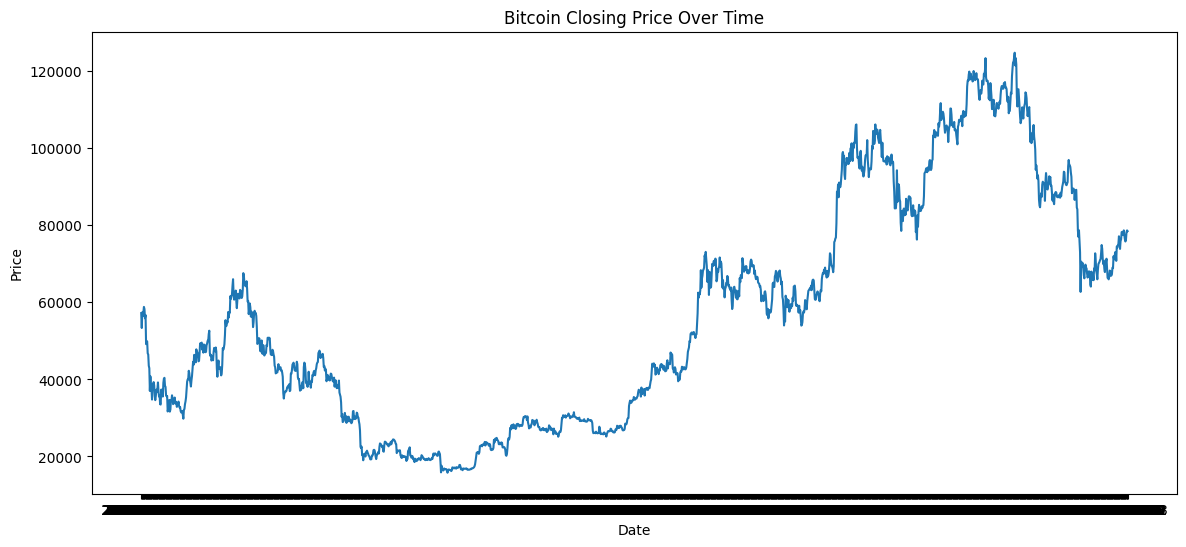

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

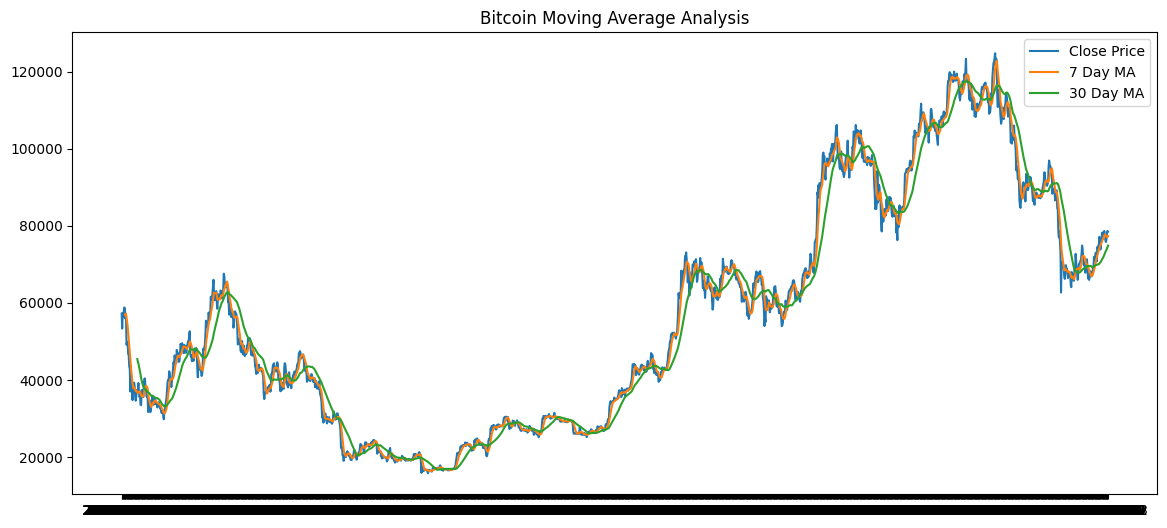

In [20]:
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_7'], label='7 Day MA')
plt.plot(df['MA_30'], label='30 Day MA')

plt.legend()
plt.title("Bitcoin Moving Average Analysis")
plt.show()

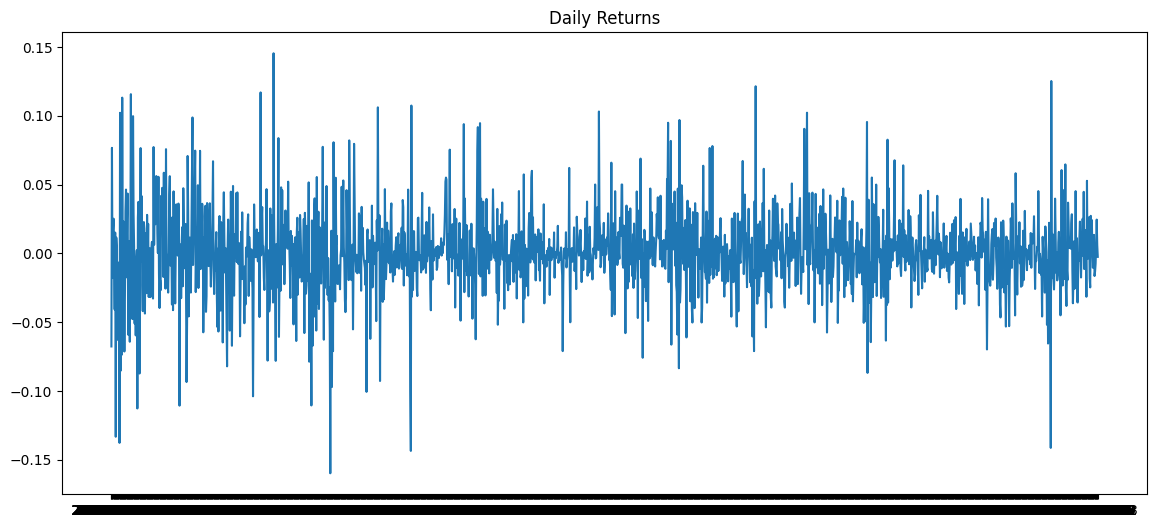

In [21]:
df['Return'] = df['Close'].pct_change()

plt.figure(figsize=(14,6))
plt.plot(df['Return'])
plt.title("Daily Returns")
plt.show()

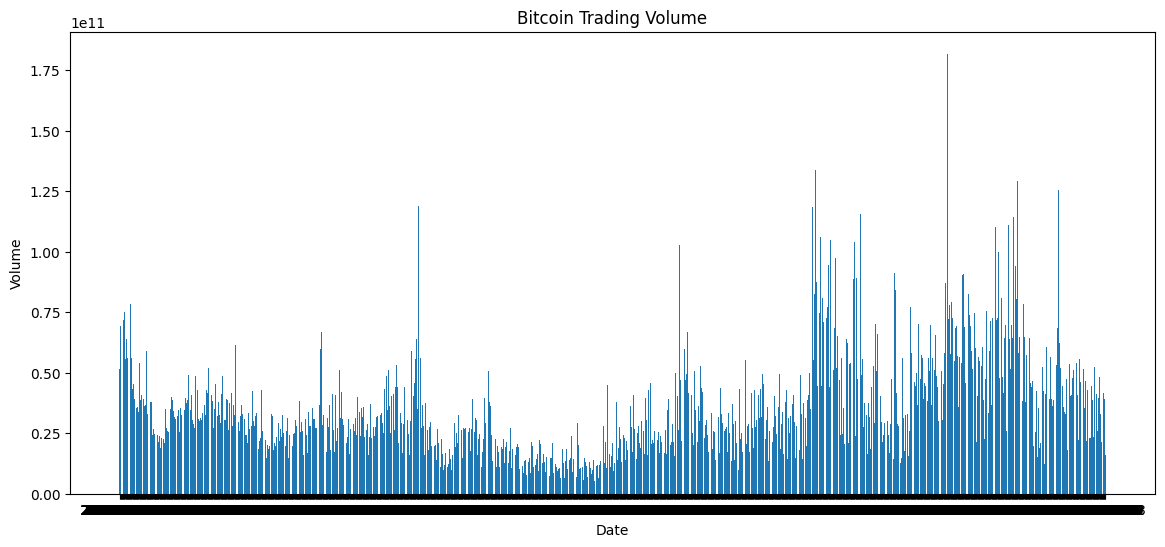

In [22]:
plt.figure(figsize=(14,6))
plt.bar(df.index, df['Volume'])
plt.title("Bitcoin Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

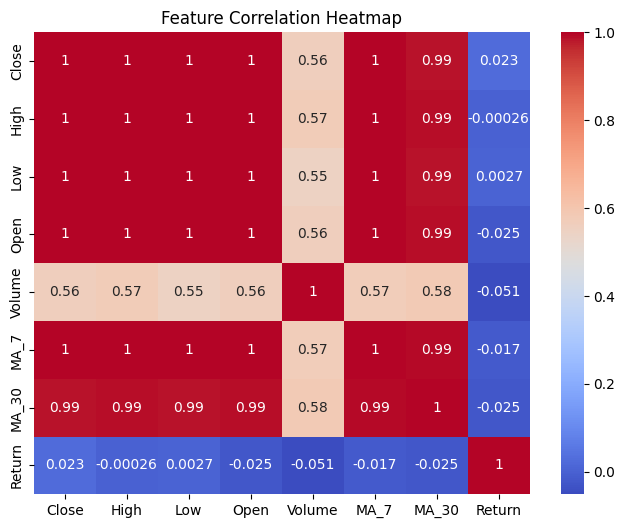

In [23]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features
features = ['Open','High','Low','Volume','MA_7','MA_30','Return','Volatility']

X = df[features]
y = df['Close']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

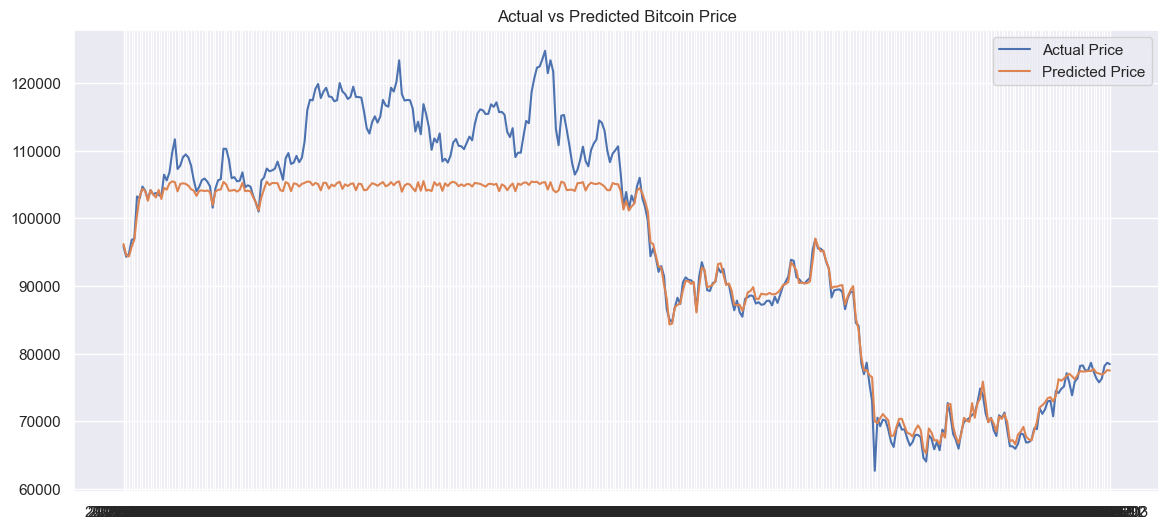

In [31]:
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="Actual Price")
plt.plot(y_test.index, predictions, label="Predicted Price")

plt.legend()
plt.title("Actual vs Predicted Bitcoin Price")
plt.show()

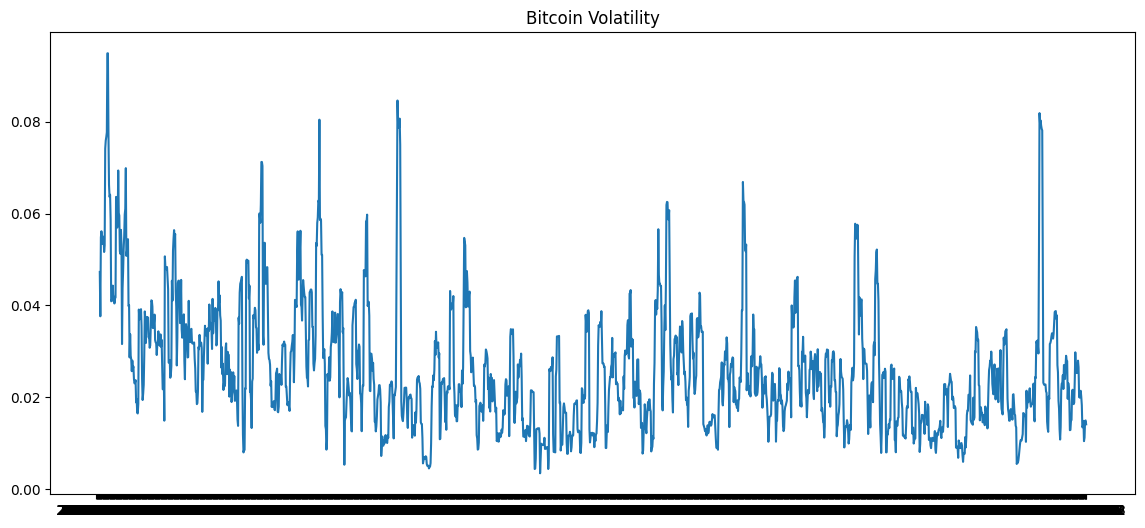

In [25]:
df['Volatility'] = df['Return'].rolling(7).std()

plt.figure(figsize=(14,6))
plt.plot(df['Volatility'])
plt.title("Bitcoin Volatility")
plt.show()

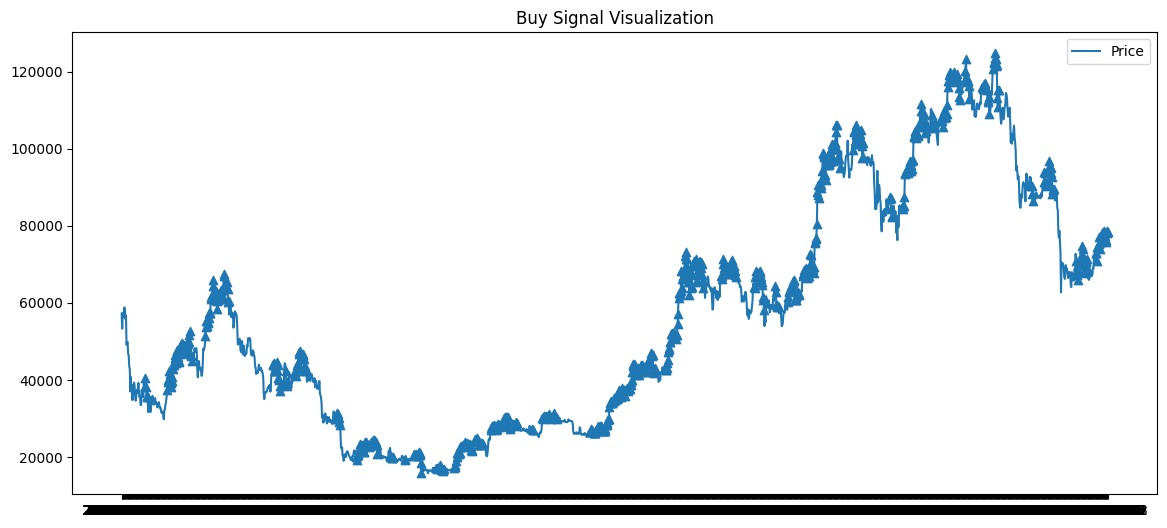

In [26]:
df['Signal'] = 0
df.loc[df['MA_7'] > df['MA_30'], 'Signal'] = 1

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label="Price")
plt.scatter(df.index[df['Signal']==1],
            df['Close'][df['Signal']==1],
            marker='^')

plt.title("Buy Signal Visualization")
plt.legend()
plt.show()

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

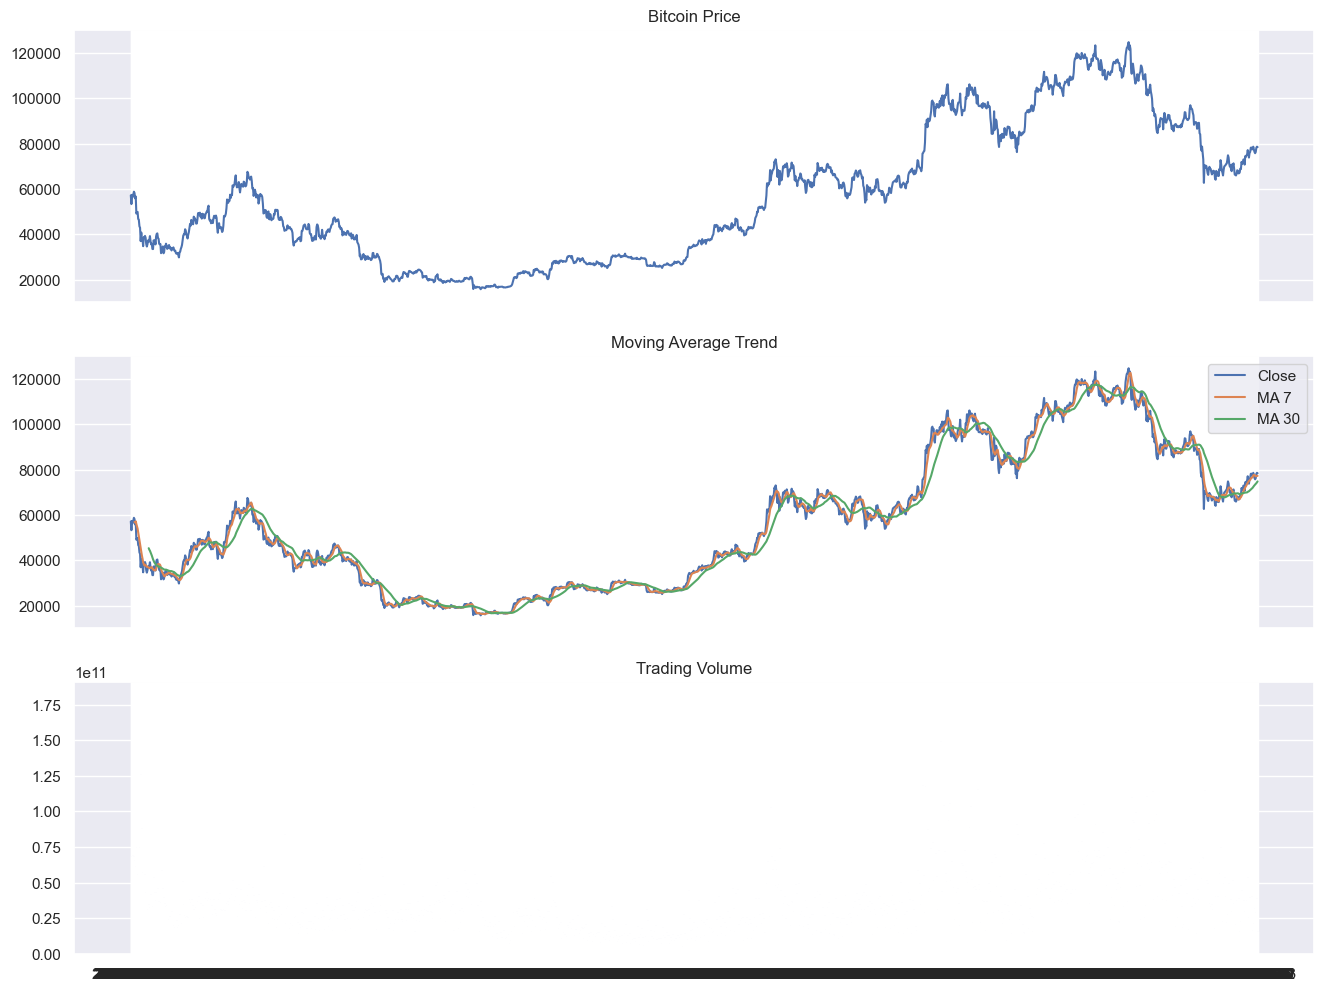

In [28]:
fig, ax = plt.subplots(3, 1, figsize=(16,12), sharex=True)

# Price
ax[0].plot(df['Close'])
ax[0].set_title("Bitcoin Price")

# Moving Averages
ax[1].plot(df['Close'], label="Close")
ax[1].plot(df['MA_7'], label="MA 7")
ax[1].plot(df['MA_30'], label="MA 30")
ax[1].legend()
ax[1].set_title("Moving Average Trend")

# Volume
ax[2].bar(df.index, df['Volume'])
ax[2].set_title("Trading Volume")

plt.show()

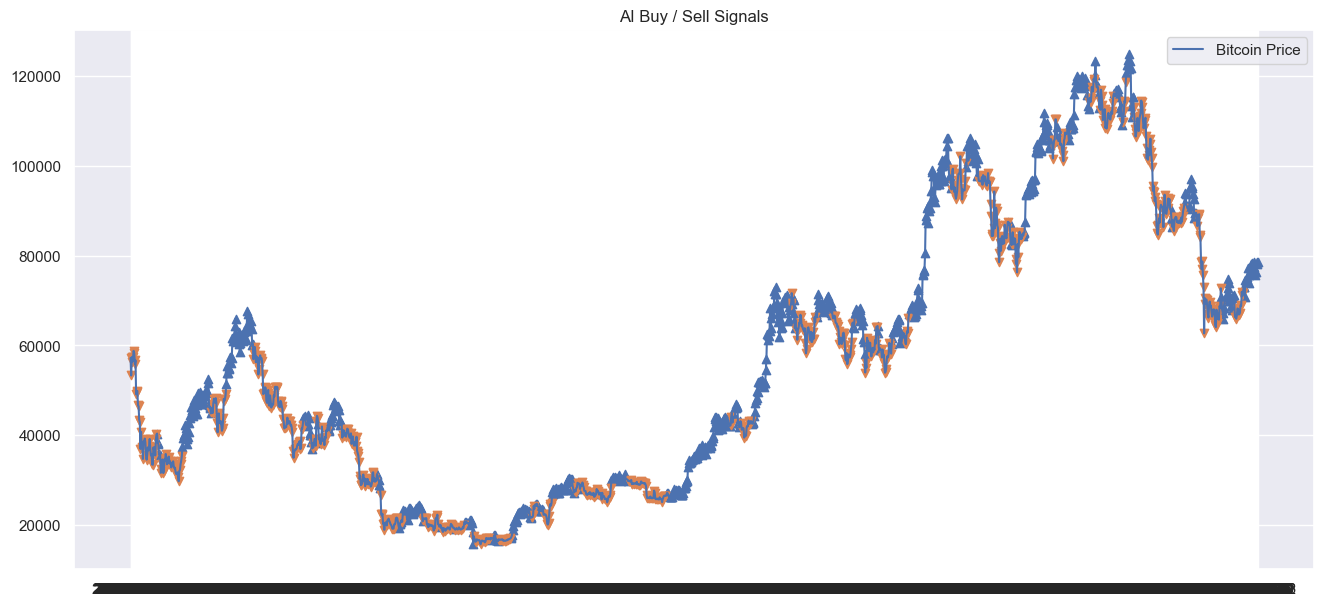

In [29]:
df['Signal'] = 0
df.loc[df['MA_7'] > df['MA_30'], 'Signal'] = 1

plt.figure(figsize=(16,7))

plt.plot(df['Close'], label="Bitcoin Price")

plt.scatter(
    df.index[df['Signal']==1],
    df['Close'][df['Signal']==1],
    marker="^"
)

plt.scatter(
    df.index[df['Signal']==0],
    df['Close'][df['Signal']==0],
    marker="v"
)

plt.title("AI Buy / Sell Signals")
plt.legend()
plt.show()

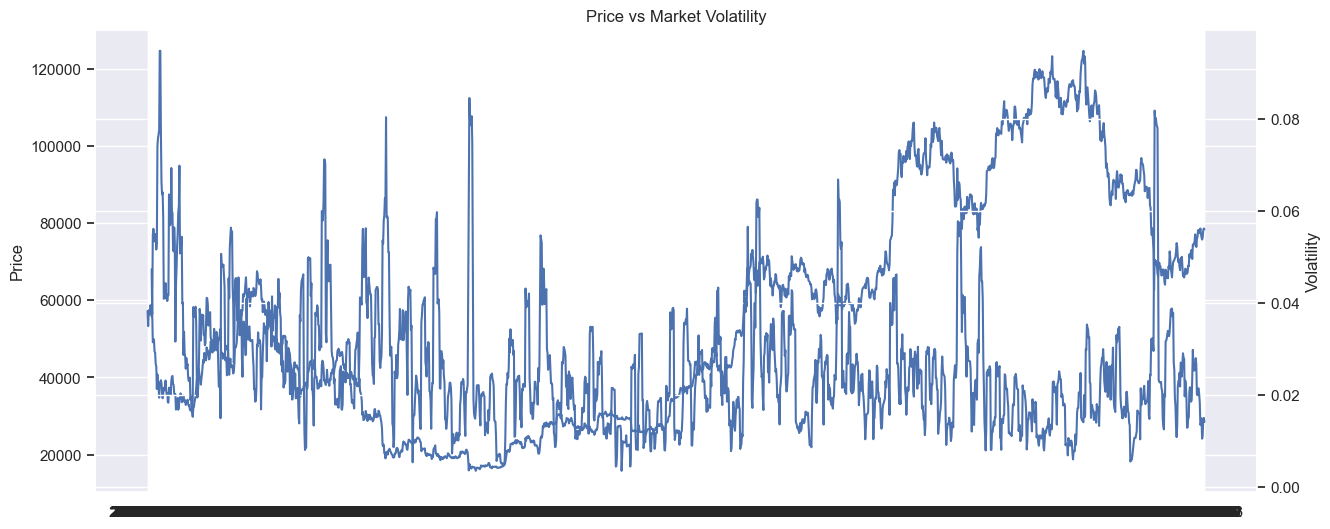

In [32]:
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.plot(df['Close'])
ax1.set_ylabel("Price")

ax2 = ax1.twinx()
ax2.plot(df['Volatility'])
ax2.set_ylabel("Volatility")

plt.title("Price vs Market Volatility")
plt.show()

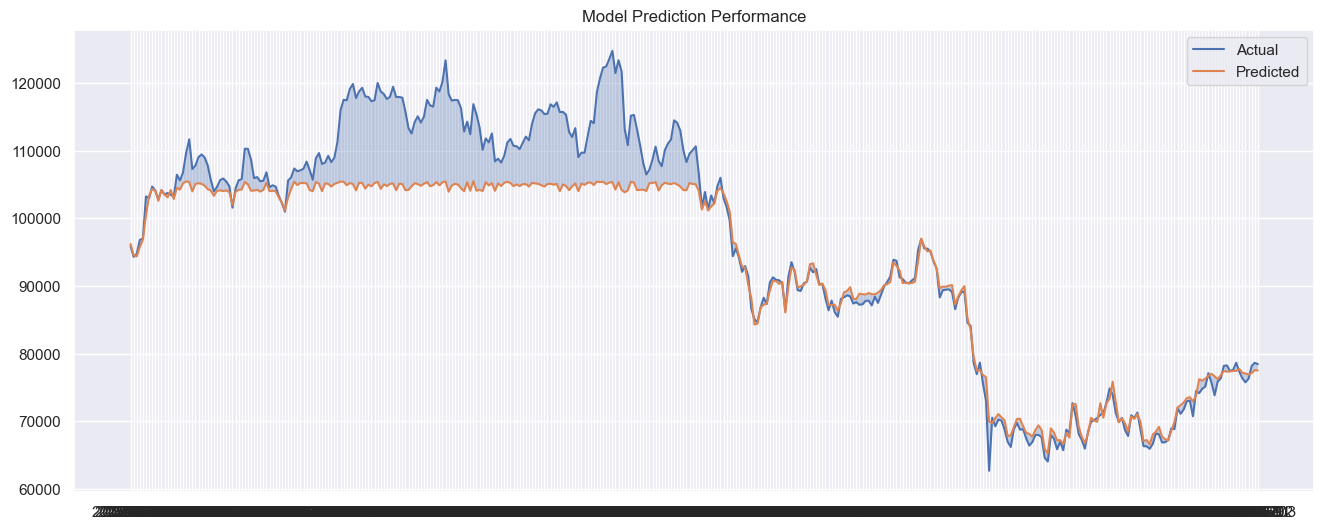

In [33]:
plt.figure(figsize=(16,6))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, predictions, label="Predicted")

plt.fill_between(
    y_test.index,
    y_test,
    predictions,
    alpha=0.3
)

plt.title("Model Prediction Performance")
plt.legend()
plt.show()

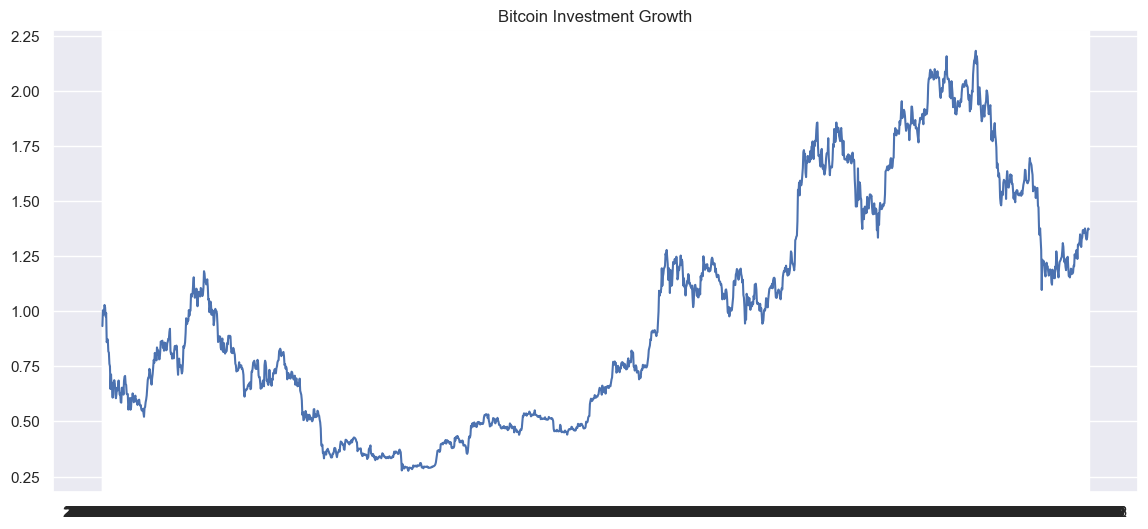

In [34]:
df['Cumulative_Return'] = (1 + df['Return']).cumprod()

plt.figure(figsize=(14,6))
plt.plot(df['Cumulative_Return'])
plt.title("Bitcoin Investment Growth")
plt.show()

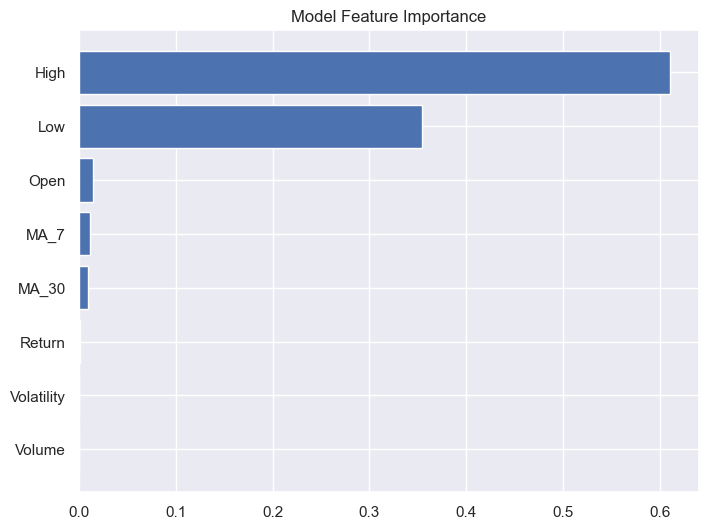

In [35]:
import pandas as pd

importance = model.feature_importances_
feature_names = X.columns

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance")

plt.figure(figsize=(8,6))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Model Feature Importance")
plt.show()

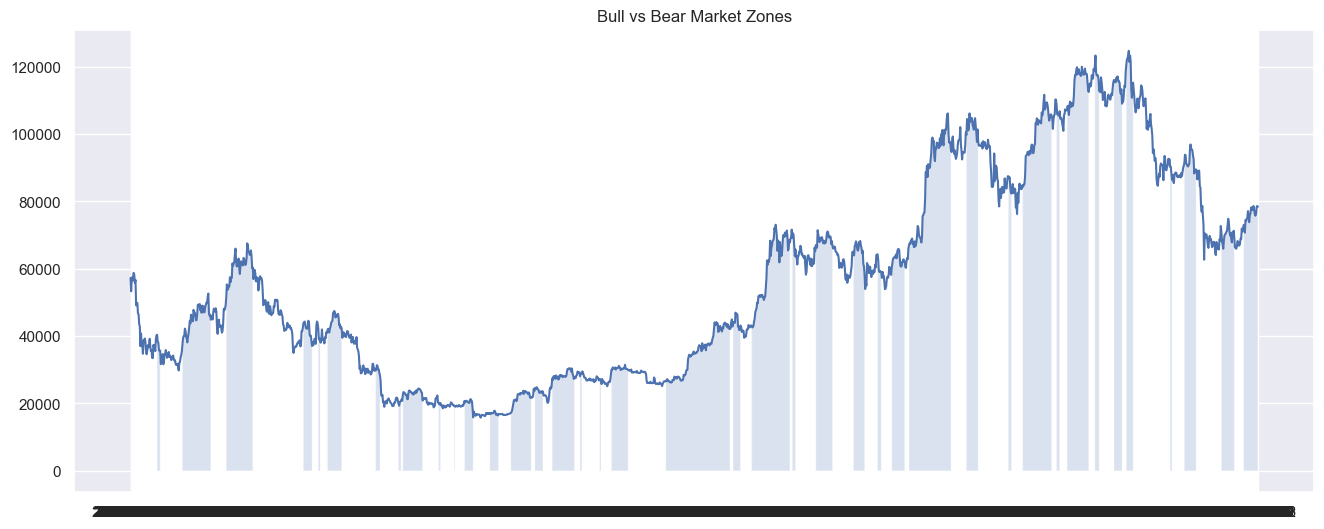

In [36]:
plt.figure(figsize=(16,6))

plt.plot(df['Close'])

plt.fill_between(
    df.index,
    df['Close'],
    where=df['MA_7']>df['MA_30'],
    alpha=0.2
)

plt.title("Bull vs Bear Market Zones")
plt.show()

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(
    "bitcoin_5y_data.csv",
    index_col=0,
    parse_dates=True
)

df.columns = df.columns.str.strip()

# Clean numbers
df = df.replace(',', '', regex=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

df.head()

C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_31784\1161125125.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,Close,High,Low,Open,Volume
Price,,,,,
2021-05-03,57200.292969,58973.308594,56590.871094,56620.273438,5.171314e+10
2021-05-04,53333.539062,57214.179688,53191.425781,57214.179688,6.856471e+10
2021-05-05,57424.007812,57911.363281,52969.054688,53252.164062,6.924132e+10
2021-05-06,56396.515625,58363.316406,55382.507812,57441.308594,6.952329e+10
2021-05-07,57356.402344,58606.632812,55321.847656,56413.953125,6.843402e+10


In [42]:
df.index = pd.to_datetime(df.index)

In [43]:
import pandas as pd
import mplfinance as mpf

df = pd.read_csv(
    "bitcoin_5y_data.csv",
    index_col=0
)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

# Clean columns
df.columns = df.columns.str.strip()

# Convert numeric
df = df.replace(',', '', regex=True)
df = df.astype(float)

# Candlestick Chart
mpf.plot(
    df.tail(200),
    type='candle',
    style='charles',
    volume=True,
    title="Bitcoin Candlestick Chart"
)

C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_31784\2820441787.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


DateParseError: Unknown datetime string format, unable to parse: Ticker

In [39]:
data = df[['Close']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

print(X.shape)

(1767, 60, 1)


In [40]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

C:\Users\JAISH DAHIYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - loss: 0.0088
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0025
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0020
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0018
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0017
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0017
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0017
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0017
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0015
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0015


In [45]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


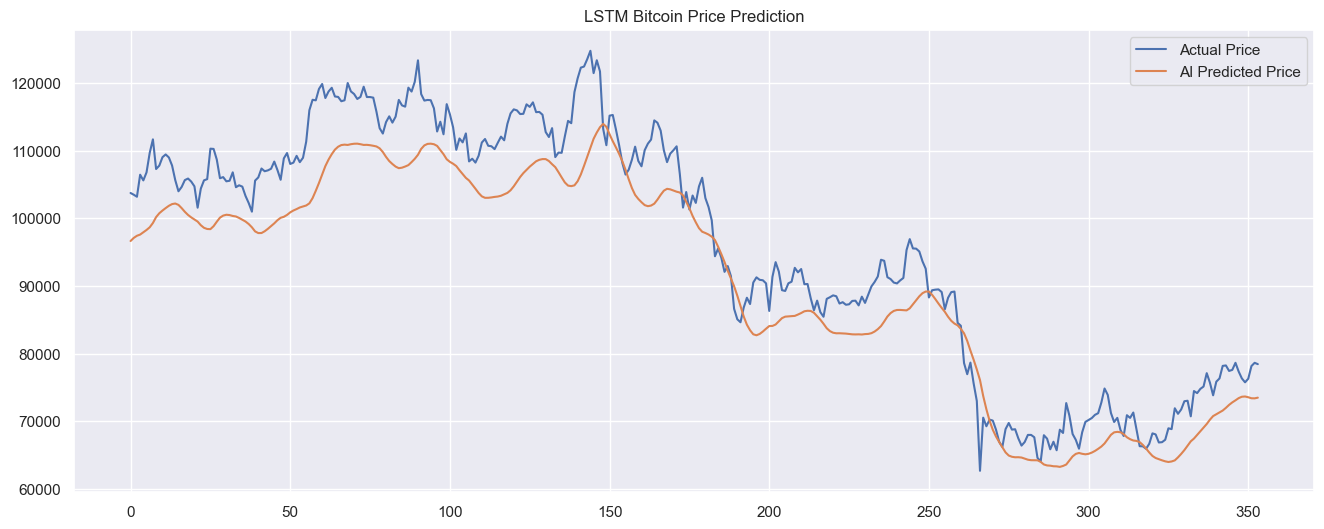

In [46]:
plt.figure(figsize=(16,6))

plt.plot(y_test_real, label="Actual Price")
plt.plot(predictions, label="AI Predicted Price")

plt.title("LSTM Bitcoin Price Prediction")
plt.legend()
plt.show()

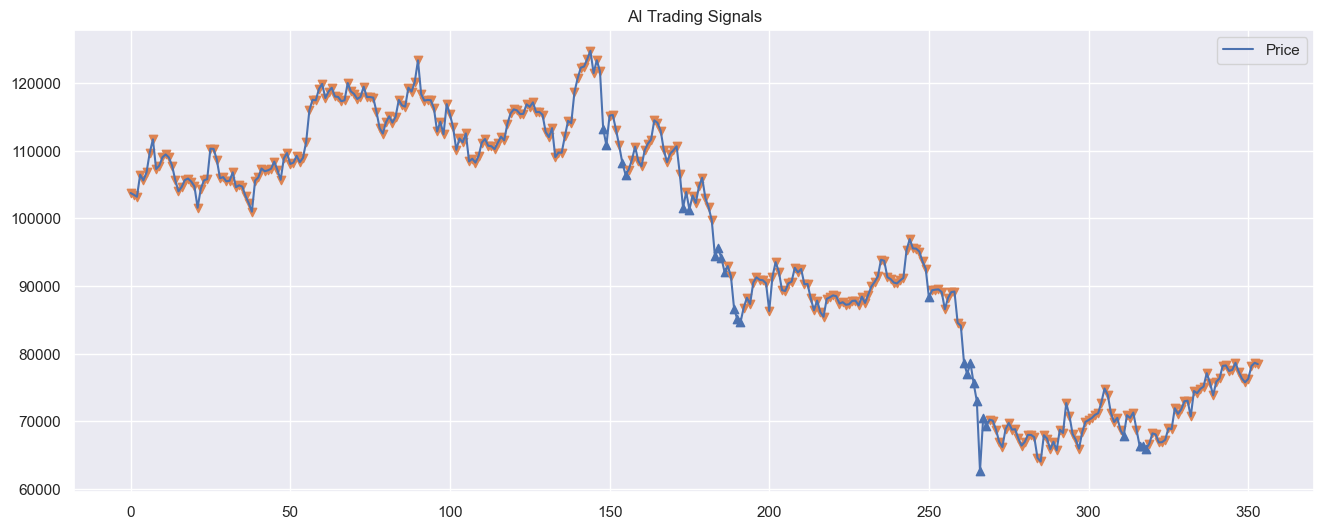

In [47]:
signals = pd.DataFrame()
signals['Actual'] = y_test_real.flatten()
signals['Predicted'] = predictions.flatten()

signals['Signal'] = 0
signals.loc[signals['Predicted'] >
            signals['Actual'], 'Signal'] = 1

plt.figure(figsize=(16,6))

plt.plot(signals['Actual'], label="Price")

plt.scatter(
    signals.index[signals['Signal']==1],
    signals['Actual'][signals['Signal']==1],
    marker='^'
)

plt.scatter(
    signals.index[signals['Signal']==0],
    signals['Actual'][signals['Signal']==0],
    marker='v'
)

plt.title("AI Trading Signals")
plt.legend()
plt.show()